# 🚲 The Changing Shape of Capital Bikeshare Demand

A descriptive comparison of demand composition and hourly usage patterns in Washington, D.C., 2011–2012.


# 🧰 Preparation


## Import


In [1]:
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd

from utils import print_duplicate_count, save_fig


/home/dev/DA/Experimental/BikeshareDemandShifts/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configure


In [2]:
pd.set_option("display.max_rows", None)


## Define Constants


In [3]:
SEED = 42

RENTAL_COLUMNS = ["casual", "registered", "cnt"]
NORMALIZED_COLUMNS = ["temp", "atemp", "hum", "windspeed"]

DAILY_VARIABLES = [
    "instant",
    "dteday",
    "yr",
    "mnth",
    "holiday",
    "workingday",
    "casual",
    "registered",
    "cnt",
    "year",
    "day_type",
]
HOURLY_VARIABLES = DAILY_VARIABLES + ["hr"]


# 🗃️ 1. Data Wrangling


## 1.1 Data Gathering


### Download Dataset


In [4]:
dataset_path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Path to dataset files:", dataset_path)


Path to dataset files: /home/dev/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1


### Load Dataset


In [5]:
hourly_df = pd.read_csv(f"{dataset_path}/hour.csv")

hourly_df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [6]:
daily_df = pd.read_csv(f"{dataset_path}/day.csv")

daily_df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## 1.2 Data Quality Assessment


### Hourly Dataset


#### Data Types and Missing Values

Insights:

- 🚩 The `dteday` column is stored as an `str` data type rather than as `datetime` objects.

- ✅ No columns contain missing values.


In [7]:
hourly_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


#### Duplicate Rows

Insights:

- ✅ No exact or temporal duplicate observations.


In [8]:
print_duplicate_count(hourly_df)


Total number of duplicate rows: 0


np.int64(0)

In [9]:
hourly_temporal_duplicates = hourly_df.duplicated(subset=["dteday", "hr"]).sum()

print("Duplicate date-hour in observations:", hourly_temporal_duplicates)


Duplicate date-hour in observations: 0


#### Inaccurate Values

Insights:

- ✅ Numerical column distribution behaves as expected (no anomalies).


In [10]:
hourly_df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instant,17379.0,NaN,NaN,NaN,8690.0,5017.0295,1.0,4345.5,8690.0,13034.5,17379.0
dteday,17379,731,2011-01-01,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,17379.0,NaN,NaN,NaN,2.50164,1.106918,1.0,2.0,3.0,3.0,4.0
yr,17379.0,NaN,NaN,NaN,0.502561,0.500008,0.0,0.0,1.0,1.0,1.0
mnth,17379.0,NaN,NaN,NaN,6.537775,3.438776,1.0,4.0,7.0,10.0,12.0
hr,17379.0,NaN,NaN,NaN,11.546752,6.914405,0.0,6.0,12.0,18.0,23.0
holiday,17379.0,NaN,NaN,NaN,0.02877,0.167165,0.0,0.0,0.0,0.0,1.0
weekday,17379.0,NaN,NaN,NaN,3.003683,2.005771,0.0,1.0,3.0,5.0,6.0
workingday,17379.0,NaN,NaN,NaN,0.682721,0.465431,0.0,0.0,1.0,1.0,1.0
weathersit,17379.0,NaN,NaN,NaN,1.425283,0.639357,1.0,1.0,1.0,2.0,4.0


### Daily Dataset


#### Data Types and Missing Values

Insights:

- 🚩 The `dteday` column is stored as an `str` data type rather than as `datetime` objects.

- ✅ No columns contain missing values.


In [11]:
daily_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


#### Duplicate Rows

Insights:

- ✅ No exact or temporal duplicate observations.


In [12]:
print_duplicate_count(daily_df)


Total number of duplicate rows: 0


np.int64(0)

In [13]:
daily_temporal_duplicates = daily_df.duplicated(subset=["dteday"]).sum()

print("Duplicate dates in observations:", daily_temporal_duplicates)


Duplicate dates in observations: 0


#### Inaccurate Values

Insights:

- ✅ Numerical column distribution behaves as expected (no anomalies).


In [14]:
daily_df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instant,731.0,NaN,NaN,NaN,366.0,211.165812,1.0,183.5,366.0,548.5,731.0
dteday,731,731,2011-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,731.0,NaN,NaN,NaN,2.49658,1.110807,1.0,2.0,3.0,3.0,4.0
yr,731.0,NaN,NaN,NaN,0.500684,0.500342,0.0,0.0,1.0,1.0,1.0
mnth,731.0,NaN,NaN,NaN,6.519836,3.451913,1.0,4.0,7.0,10.0,12.0
holiday,731.0,NaN,NaN,NaN,0.028728,0.167155,0.0,0.0,0.0,0.0,1.0
weekday,731.0,NaN,NaN,NaN,2.997264,2.004787,0.0,1.0,3.0,5.0,6.0
workingday,731.0,NaN,NaN,NaN,0.683995,0.465233,0.0,0.0,1.0,1.0,1.0
weathersit,731.0,NaN,NaN,NaN,1.395349,0.544894,1.0,1.0,1.0,2.0,3.0
temp,731.0,NaN,NaN,NaN,0.495385,0.183051,0.05913,0.337083,0.498333,0.655417,0.861667


### Conclusion

Overall, both datasets are complete, duplicate-free, and internally plausible, with `dteday` requiring conversion from `str` to `datetime`. Also, ensure that both datasets are sorted chronologically before analysis.


### Data Cleaning


#### Convert String Observation Dates to Datetime


In [15]:
for df in [hourly_df, daily_df]:
    df["dteday"] = pd.to_datetime(df["dteday"])
    print("Result:", df["dteday"].dtype)


Result: datetime64[us]
Result: datetime64[us]


#### Sort the Datasets Chronologically


In [16]:
hourly_df = hourly_df.sort_values(["dteday", "hr"]).reset_index(drop=True)

daily_df = daily_df.sort_values("dteday").reset_index(drop=True)


## 1.3 Data Consistency Assessment


### Cross-Field Consistency


#### Validate Rental Count Integrity


In [17]:
def validate_rental_counts(df, dataset_name):
    invalid_count = (df["cnt"] != df["casual"] + df["registered"]).sum()

    return {"dataset": dataset_name, "invalid_rental_totals": invalid_count}


pd.DataFrame(
    [
        validate_rental_counts(hourly_df, "Hourly"),
        validate_rental_counts(daily_df, "Daily"),
    ]
)


,dataset,invalid_rental_totals
0,Hourly,0
1,Daily,0


#### Validate Hourly Rental-Count Aggregates Against Daily Records


In [18]:
hourly_daily = hourly_df.groupby("dteday", as_index=False)[RENTAL_COLUMNS].sum()

reconciliation = daily_df[["dteday"] + RENTAL_COLUMNS].merge(
    hourly_daily,
    on="dteday",
    how="outer",
    suffixes=("_daily", "_hourly"),
    indicator=True,
    validate="one_to_one",
)

reconciliation.head()


,dteday,casual_daily,registered_daily,cnt_daily,casual_hourly,registered_hourly,cnt_hourly,_merge
0,2011-01-01,331,654,985,331,654,985,both
1,2011-01-02,131,670,801,131,670,801,both
2,2011-01-03,120,1229,1349,120,1229,1349,both
3,2011-01-04,108,1454,1562,108,1454,1562,both
4,2011-01-05,82,1518,1600,82,1518,1600,both


In [19]:
for column in RENTAL_COLUMNS:
    reconciliation[f"{column}_difference"] = (
        reconciliation[f"{column}_daily"] - reconciliation[f"{column}_hourly"]
    )

difference_columns = [
    "casual_difference",
    "registered_difference",
    "cnt_difference",
]

mismatches = reconciliation[
    # Date exists in only one dataset.
    reconciliation["_merge"].ne("both")
    # At least one rental total is different. Axis 1 = columns.
    | reconciliation[difference_columns].ne(0).any(axis=1)
]

print("Dates with hourly-daily rental discrepancies:", len(mismatches))

mismatches


Dates with hourly-daily rental discrepancies: 0


,dteday,casual_daily,registered_daily,cnt_daily,casual_hourly,registered_hourly,cnt_hourly,_merge,casual_difference,registered_difference,cnt_difference


#### Validate Encoded Year, Month, and Day of Week Against the Date


In [20]:
def validate_temporal_codes(df, dataset_name):
    expected_year = df["dteday"].dt.year - 2011
    expected_month = df["dteday"].dt.month
    # In the dataset, 0 = Sunday, not Monday.
    expected_weekday = (df["dteday"].dt.dayofweek + 1) % 7

    return {
        "dataset": dataset_name,
        "year_mismatches": (df["yr"] != expected_year).sum(),
        "month_mismatches": (df["mnth"] != expected_month).sum(),
        "weekday_mismatches": (df["weekday"] != expected_weekday).sum(),
    }


pd.DataFrame(
    [
        validate_temporal_codes(hourly_df, "Hourly"),
        validate_temporal_codes(daily_df, "Daily"),
    ]
)


,dataset,year_mismatches,month_mismatches,weekday_mismatches
0,Hourly,0,0,0
1,Daily,0,0,0


### Validate Ranges


#### Validate Categorical Codes


In [21]:
expected_categories = {
    "season": {1, 2, 3, 4},
    "yr": {0, 1},
    "mnth": set(range(1, 13)),
    "holiday": {0, 1},
    "weekday": set(range(7)),
    "workingday": {0, 1},
    "weathersit": {1, 2, 3, 4},
}

hourly_categories = {
    **expected_categories,
    "hr": set(range(24)),
}


def validate_categories(df, expected_values, dataset_name):
    results = []

    for column, valid_values in expected_values.items():
        observed_values = set(df[column].unique())
        invalid_values = sorted(observed_values - valid_values)

        results.append(
            {
                "dataset": dataset_name,
                "column": column,
                "invalid_values": invalid_values,
                "is_valid": len(invalid_values) == 0,
            }
        )

    return pd.DataFrame(results)


category_validation = pd.concat(
    [
        validate_categories(hourly_df, hourly_categories, "Hourly"),
        validate_categories(daily_df, expected_categories, "Daily"),
    ],
    ignore_index=True,
)

category_validation


,dataset,column,invalid_values,is_valid
0,Hourly,season,[],True
1,Hourly,yr,[],True
2,Hourly,mnth,[],True
3,Hourly,holiday,[],True
4,Hourly,weekday,[],True
5,Hourly,workingday,[],True
6,Hourly,weathersit,[],True
7,Hourly,hr,[],True
8,Daily,season,[],True
9,Daily,yr,[],True


#### Validate Normalized Environmental Variables Ranges


In [22]:
def validate_normalized_ranges(df, dataset_name):
    results = []

    for column in NORMALIZED_COLUMNS:
        values = df[column]

        results.append(
            {
                "dataset": dataset_name,
                "column": column,
                "minimum": values.min(),
                "maximum": values.max(),
                "outside_0_1": ((values < 0) | (values > 1)).sum(),
            }
        )

    return pd.DataFrame(results)


range_validation = pd.concat(
    [
        validate_normalized_ranges(hourly_df, "Hourly"),
        validate_normalized_ranges(daily_df, "Daily"),
    ],
    ignore_index=True,
)

range_validation


,dataset,column,minimum,maximum,outside_0_1
0,Hourly,temp,0.020000,1.000000,0
1,Hourly,atemp,0.000000,1.000000,0
2,Hourly,hum,0.000000,1.000000,0
3,Hourly,windspeed,0.000000,0.850700,0
4,Daily,temp,0.059130,0.861667,0
5,Daily,atemp,0.079070,0.840896,0
6,Daily,hum,0.000000,0.972500,0
7,Daily,windspeed,0.022392,0.507463,0


### Data Coverage


#### Validate Date Coverage


In [23]:
expected_dates = pd.date_range(
    "2011-01-01",
    "2012-12-31",
    freq="D",
)


def validate_date_coverage(df, dataset_name):
    # Extract unique dates from the hourly dataset.
    observed_dates = pd.DatetimeIndex(df["dteday"].unique())

    missing_dates = expected_dates.difference(observed_dates)

    return {
        "dataset": dataset_name,
        "start_date": observed_dates.min(),
        "end_date": observed_dates.max(),
        "observed_dates": len(observed_dates),
        "expected_dates": len(expected_dates),
        "missing_dates": len(missing_dates),
    }


pd.DataFrame(
    [
        validate_date_coverage(hourly_df, "Hourly"),
        validate_date_coverage(daily_df, "Daily"),
    ]
)


,dataset,start_date,end_date,observed_dates,expected_dates,missing_dates
0,Hourly,2011-01-01,2012-12-31,731,731,0
1,Daily,2011-01-01,2012-12-31,731,731,0


#### Validate Hourly Coverage


In [24]:
# Create every expected date-hour combination.
expected_hours = daily_df[["dteday", "workingday"]].merge(
    pd.DataFrame({"hr": range(24)}),
    # Date × Working Day × Hour.
    how="cross",
)

# Get the existing date-hour combinations and assign `True` to a new column called `observed`.
observed_hours = hourly_df[["dteday", "hr"]].assign(observed=True)

# Match expected hours with observed hours.
coverage = expected_hours.merge(
    observed_hours,
    on=["dteday", "hr"],
    how="left",
)

# Missing values in `observed` indicating missing observed hours.
coverage["is_missing"] = coverage["observed"].isna()

# Add useful grouping variables for later use.
coverage["year"] = coverage["dteday"].dt.year
coverage["day_type"] = coverage["workingday"].map(
    {1: "Working Day", 0: "Non-Working Day"}
)

coverage.head()


,dteday,workingday,hr,observed,is_missing,year,day_type
0,2011-01-01,0,0,True,False,2011,Non-Working Day
1,2011-01-01,0,1,True,False,2011,Non-Working Day
2,2011-01-01,0,2,True,False,2011,Non-Working Day
3,2011-01-01,0,3,True,False,2011,Non-Working Day
4,2011-01-01,0,4,True,False,2011,Non-Working Day


In [25]:
print("Expected hourly observations:", len(coverage))
print("Observed hourly observations:", (~coverage["is_missing"]).sum())
print("Missing hourly observations:", coverage["is_missing"].sum())
print(f"Missing percentage: {coverage['is_missing'].mean() * 100:.2f}%")


Expected hourly observations: 17544
Observed hourly observations: 17379
Missing hourly observations: 165
Missing percentage: 0.94%


In [26]:
def missing_summary(group):
    summary = coverage.groupby(group)["is_missing"].agg(
        # Total row count.
        expected_hours="size",
        missing_hours="sum",
    )

    summary["missing_pct"] = (
        summary["missing_hours"] / summary["expected_hours"] * 100
    ).round(2)

    return summary


print("Missing by year:")
display(missing_summary("year"))

print("\nMissing by hour:")
display(missing_summary("hr"))

print("\nMissing by day type:")
display(missing_summary("day_type"))


Missing by year:


,expected_hours,missing_hours,missing_pct
year,,,
2011,8760,115,1.31
2012,8784,50,0.57



Missing by hour:


,expected_hours,missing_hours,missing_pct
hr,,,
0,731,5,0.68
1,731,7,0.96
2,731,16,2.19
3,731,34,4.65
4,731,34,4.65
5,731,14,1.92
6,731,6,0.82
7,731,4,0.55
8,731,4,0.55



Missing by day type:


,expected_hours,missing_hours,missing_pct
day_type,,,
Non-Working Day,5544,30,0.54
Working Day,12000,135,1.12


### Logical Consistency


#### Validate Working-Day Logic


In [27]:
def validate_workingday(df, dataset_name):
    is_weekend = df["dteday"].dt.dayofweek >= 5

    expected_workingday = (~is_weekend) & ~df["holiday"]

    return {
        "dataset": dataset_name,
        "workingday_mismatches": (df["workingday"] != expected_workingday).sum(),
    }


pd.DataFrame(
    [
        validate_workingday(hourly_df, "Hourly"),
        validate_workingday(daily_df, "Daily"),
    ]
)


,dataset,workingday_mismatches
0,Hourly,0
1,Daily,0


In [28]:
daily_df[["weekday", "holiday", "workingday"]].drop_duplicates().sort_values(
    ["weekday", "holiday"]
).reset_index(drop=True)


,weekday,holiday,workingday
0,0,0,0
1,1,0,1
2,1,1,0
3,2,0,1
4,2,1,0
5,3,0,1
6,3,1,0
7,4,0,1
8,4,1,0
9,5,0,1


### Overall Insights

- ✅ Rental counts are internally consistent. In both datasets, `cnt = casual + registered` for every record.

- ✅ Hourly and daily totals reconcile perfectly. Aggregated hourly rental counts match the daily records for all dates.

- ✅ Temporal fields are valid. `yr`, `mnth`, and `weekday` match the calendar date in both datasets.

- ✅ Categorical codes are valid. No out-of-range values were found in the categorical variables.

- ✅ Normalized environmental variables are valid. `temp`, `atemp`, `hum`, and `windspeed` all remain within the 0–1 range.

- ✅ Date coverage is complete. Both datasets cover all 731 days from January 1, 2011 to December 31, 2012.

- ⚠️ Hourly coverage is slightly incomplete. There are 165 missing date-hour combinations, equal to 0.94% of all expected hourly observations.

- ⚠️ Hourly missingness is uneven. Missing hours are more common in 2011, on working days, and around 3:00–4:00 AM, so these differences should be considered when comparing hourly patterns.

- ⚠️ Missing hours should not be automatically imputed. Daily totals already reconcile with the observed hourly records, so the absent hours require careful interpretation rather than immediate replacement.

- ✅ Working-day logic is consistent. Weekends and holidays are correctly classified as non-working days.


### Conclusion

Data consistency is strong. No major structural or logical errors were detected. The main consideration is the small amount of incomplete hourly coverage.


## 1.4 Outlier Assessment


### Assess


In [29]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


def detect_outliers(df, column):
    lower_bound, upper_bound = iqr_bounds(df[column])

    return (
        (df[column] < lower_bound) | (df[column] > upper_bound),
        lower_bound,
        upper_bound,
    )


def assess_outliers(df, columns, dataset_name):
    results = []

    for column in columns:
        is_outlier, lower_bound, upper_bound = detect_outliers(df, column)

        results.append(
            {
                "dataset": dataset_name,
                "column": column,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "outlier_count": is_outlier.sum(),
                "outlier_pct": round(is_outlier.mean() * 100, 2),
            }
        )

    return pd.DataFrame(results)


In [30]:
outlier_summary = pd.concat(
    [
        assess_outliers(hourly_df, RENTAL_COLUMNS, "Hourly"),
        assess_outliers(daily_df, RENTAL_COLUMNS, "Daily"),
    ],
    ignore_index=True,
)

outlier_summary


,dataset,column,lower_bound,upper_bound,outlier_count,outlier_pct
0,Hourly,casual,-62.00,114.00,1192,6.86
1,Hourly,registered,-245.00,499.00,680,3.91
2,Hourly,cnt,-321.50,642.50,505,2.91
3,Daily,casual,-855.25,2266.75,44,6.02
4,Daily,registered,-922.25,8195.75,0,0.00
5,Daily,cnt,-1054.00,10162.00,0,0.00


In [31]:
hourly_cnt_outlier_mask = detect_outliers(hourly_df, "cnt")[0]
hourly_cnt_outliers = hourly_df[hourly_cnt_outlier_mask]


hourly_cnt_outliers[["dteday", "hr"] + RENTAL_COLUMNS].sort_values(
    "cnt", ascending=False
).head()


,dteday,hr,casual,registered,cnt
14773,2012-09-12,18,91,886,977
14964,2012-09-20,17,91,885,976
14748,2012-09-11,17,168,802,970
14725,2012-09-10,18,111,857,968
15084,2012-09-25,17,107,860,967


In [32]:
daily_casual_outlier_mask = detect_outliers(daily_df, "casual")[0]
daily_casual_outliers = daily_df[daily_casual_outlier_mask]


daily_casual_outliers[["dteday"] + RENTAL_COLUMNS].sort_values(
    "casual", ascending=False
).head()


,dteday,casual,registered,cnt
504,2012-05-19,3410,4884,8294
512,2012-05-27,3283,3308,6591
462,2012-04-07,3252,3605,6857
623,2012-09-15,3160,5554,8714
441,2012-03-17,3155,4681,7836


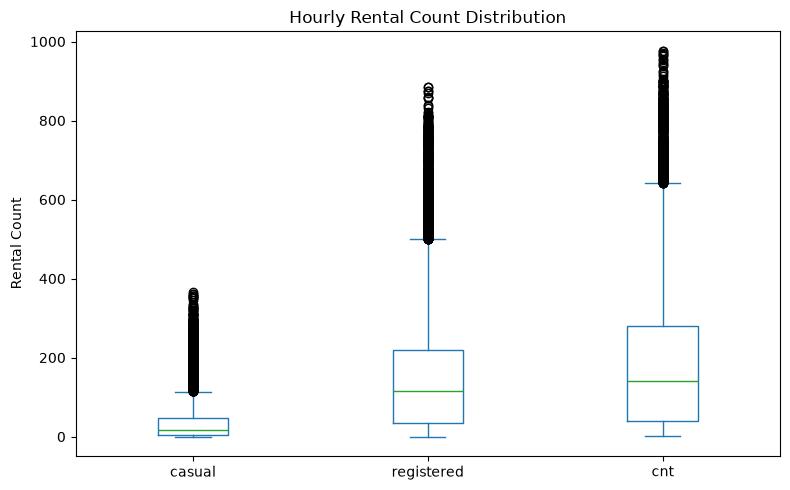

In [33]:
hourly_df[RENTAL_COLUMNS].plot(
    kind="box",
    figsize=(8, 5),
)

plt.title("Hourly Rental Count Distribution")
plt.ylabel("Rental Count")

plt.tight_layout()
plt.show()


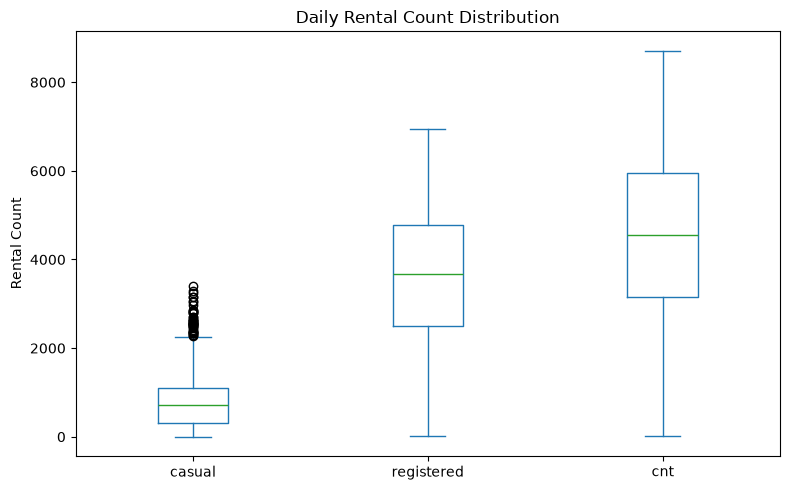

In [34]:
daily_df[RENTAL_COLUMNS].plot(
    kind="box",
    figsize=(8, 5),
)

plt.title("Daily Rental Count Distribution")
plt.ylabel("Rental Count")

plt.tight_layout()
plt.show()


### Insights

- ⚠️ Rental counts are right-skewed, with IQR-based outliers concentrated in the upper tail.

- ⚠️ In the hourly data, outliers represent 6.86% of casual, 3.91% of registered, and 2.91% of total-rental observations.

- ⚠️ In the daily data, outliers are limited to casual rentals, accounting for 6.02% of observations. None are detected for registered or total rentals.

- ✅ The flagged observations appear to reflect plausible high-demand periods rather than evident data errors and should therefore be retained.

Note:

- Negative lower IQR bounds are not practically meaningful because rental counts cannot be negative.


### Conclusion

The detected outliers reflect meaningful demand variation rather than evident data-quality issues, so the data remain suitable for descriptive analysis.


## 1.5 Feature Engineering


### Assess Feature Readability

Insight:

- 🚩 Two analysis-relevant features contain encoded categorical values: `yr` and `workingday`. These numerical codes are not immediately interpretable.

Note:

- Original encoded features should be preserved for source fidelity, while readable labels should be added for analysis and reporting.


In [35]:
hourly_df.sample(n=3, random_state=SEED).T


,12830,8688,7091
instant,12831,8689,7092
dteday,2012-06-23 00:00:00,2012-01-02 00:00:00,2011-10-28 00:00:00
season,3,1,4
yr,1,1,0
mnth,6,1,10
hr,19,20,2
holiday,0,1,0
weekday,6,1,5
workingday,0,0,1
weathersit,1,1,1


In [36]:
daily_df.sample(n=3, random_state=SEED).T


,703,33,300
instant,704,34,301
dteday,2012-12-04 00:00:00,2011-02-03 00:00:00,2011-10-28 00:00:00
season,4,1,4
yr,1,0,0
mnth,12,2,10
holiday,0,0,0
weekday,2,4,5
workingday,1,1,1
weathersit,1,1,2
temp,0.475833,0.186957,0.330833


### Add Readable Labels


In [37]:
year_labels = {0: 2011, 1: 2012}
day_type_labels = {0: "Non-Working Day", 1: "Working Day"}

for df in [hourly_df, daily_df]:
    df["year"] = df["yr"].map(year_labels)
    df["day_type"] = df["workingday"].map(day_type_labels)


## 1.6 Cleaned Data Preview


In [38]:
hourly_df.sample(n=3, random_state=SEED).T


,12830,8688,7091
instant,12831,8689,7092
dteday,2012-06-23 00:00:00,2012-01-02 00:00:00,2011-10-28 00:00:00
season,3,1,4
yr,1,1,0
mnth,6,1,10
hr,19,20,2
holiday,0,1,0
weekday,6,1,5
workingday,0,0,1
weathersit,1,1,1


In [39]:
daily_df.sample(n=3, random_state=SEED).T


,703,33,300
instant,704,34,301
dteday,2012-12-04 00:00:00,2011-02-03 00:00:00,2011-10-28 00:00:00
season,4,1,4
yr,1,0,0
mnth,12,2,10
holiday,0,0,0
weekday,2,4,5
workingday,1,1,1
weathersit,1,1,2
temp,0.475833,0.186957,0.330833


# 🔍 2. Exploratory Data Analysis


## 2.1 Dataset Overview


In [40]:
daily_df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
instant,731.0,NaN,NaN,NaN,366.0,1.0,183.5,366.0,548.5,731.0,211.165812
dteday,731,NaN,NaN,NaN,2012-01-01 00:00:00,2011-01-01 00:00:00,2011-07-02 12:00:00,2012-01-01 00:00:00,2012-07-01 12:00:00,2012-12-31 00:00:00,NaN
season,731.0,NaN,NaN,NaN,2.49658,1.0,2.0,3.0,3.0,4.0,1.110807
yr,731.0,NaN,NaN,NaN,0.500684,0.0,0.0,1.0,1.0,1.0,0.500342
mnth,731.0,NaN,NaN,NaN,6.519836,1.0,4.0,7.0,10.0,12.0,3.451913
holiday,731.0,NaN,NaN,NaN,0.028728,0.0,0.0,0.0,0.0,1.0,0.167155
weekday,731.0,NaN,NaN,NaN,2.997264,0.0,1.0,3.0,5.0,6.0,2.004787
workingday,731.0,NaN,NaN,NaN,0.683995,0.0,0.0,1.0,1.0,1.0,0.465233
weathersit,731.0,NaN,NaN,NaN,1.395349,1.0,1.0,1.0,2.0,3.0,0.544894
temp,731.0,NaN,NaN,NaN,0.495385,0.05913,0.337083,0.498333,0.655417,0.861667,0.183051


In [41]:
hourly_df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
instant,17379.0,NaN,NaN,NaN,8690.0,1.0,4345.5,8690.0,13034.5,17379.0,5017.0295
dteday,17379,NaN,NaN,NaN,2012-01-02 04:08:34.552045,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,17379.0,NaN,NaN,NaN,2.50164,1.0,2.0,3.0,3.0,4.0,1.106918
yr,17379.0,NaN,NaN,NaN,0.502561,0.0,0.0,1.0,1.0,1.0,0.500008
mnth,17379.0,NaN,NaN,NaN,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776
hr,17379.0,NaN,NaN,NaN,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
holiday,17379.0,NaN,NaN,NaN,0.02877,0.0,0.0,0.0,0.0,1.0,0.167165
weekday,17379.0,NaN,NaN,NaN,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
workingday,17379.0,NaN,NaN,NaN,0.682721,0.0,0.0,1.0,1.0,1.0,0.465431
weathersit,17379.0,NaN,NaN,NaN,1.425283,1.0,1.0,1.0,2.0,4.0,0.639357


## 2.2 Analytical Question 1

How did the volume and composition of bike-sharing demand between casual and registered users change from 2011 to 2012?


### Annual Rental Demand and User Composition


In [42]:
summary = pd.DataFrame(
    {
        "rentals_2011": (daily_df.loc[daily_df["yr"] == 0, RENTAL_COLUMNS].sum()),
        "rentals_2012": (daily_df.loc[daily_df["yr"] == 1, RENTAL_COLUMNS].sum()),
        "avg_daily_rentals_2011": (
            daily_df.loc[daily_df["yr"] == 0, RENTAL_COLUMNS].mean().round()
        ),
        "avg_daily_rentals_2012": (
            daily_df.loc[daily_df["yr"] == 1, RENTAL_COLUMNS].mean().round()
        ),
    }
)

summary["growth_rate_pct"] = (
    (summary["rentals_2012"] / summary["rentals_2011"] - 1) * 100
).round(2)

summary["absolute_change"] = summary["rentals_2012"] - summary["rentals_2011"]

summary["contribution_to_growth_pct"] = (
    summary["absolute_change"] / summary.loc["cnt", "absolute_change"] * 100
).round(2)

summary["share_2011_pct"] = (
    summary["rentals_2011"] / summary.loc["cnt", "rentals_2011"] * 100
).round(2)

summary["share_2012_pct"] = (
    summary["rentals_2012"] / summary.loc["cnt", "rentals_2012"] * 100
).round(2)

summary = summary[
    [
        "rentals_2011",
        "share_2011_pct",
        "rentals_2012",
        "share_2012_pct",
        "growth_rate_pct",
        "absolute_change",
        "contribution_to_growth_pct",
        "avg_daily_rentals_2011",
        "avg_daily_rentals_2012",
    ]
]

summary = summary.rename_axis("user_type").reset_index()

summary


,user_type,rentals_2011,share_2011_pct,rentals_2012,share_2012_pct,growth_rate_pct,absolute_change,contribution_to_growth_pct,avg_daily_rentals_2011,avg_daily_rentals_2012
0,casual,247252,19.89,372765,18.19,50.76,125513,15.56,677.0,1018.0
1,registered,995851,80.11,1676811,81.81,68.38,680960,84.44,2728.0,4581.0
2,cnt,1243103,100.00,2049576,100.00,64.88,806473,100.00,3406.0,5600.0


### Monthly Rental Trends by Year


In [43]:
monthly_rentals = daily_df.groupby(["year", "mnth"], as_index=False).agg(
    total_rentals=("cnt", "sum")
)

monthly_rentals.head()


,year,mnth,total_rentals
0,2011,1,38189
1,2011,2,48215
2,2011,3,64045
3,2011,4,94870
4,2011,5,135821


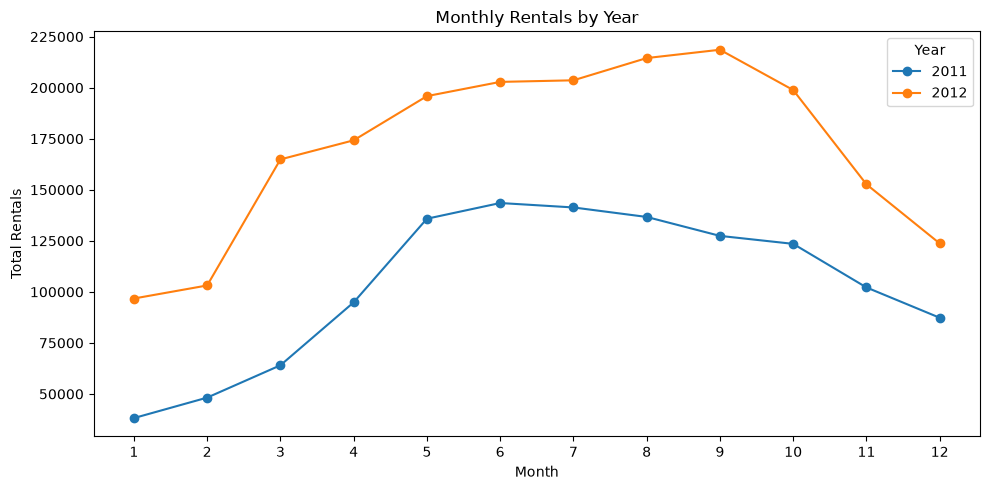

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

for year in sorted(monthly_rentals["year"].unique()):
    yearly_data = monthly_rentals[monthly_rentals["year"] == year]

    ax.plot(
        yearly_data["mnth"],
        yearly_data["total_rentals"],
        marker="o",
        label=str(year),
    )

ax.set_title("Monthly Rentals by Year")
ax.set_xlabel("Month")
ax.set_ylabel("Total Rentals")
ax.set_xticks(range(1, 13))
ax.legend(title="Year")

fig.tight_layout()

save_fig(fig, "q1_monthly_rentals_by_year")

plt.show()


## 2.3 Analytical Question 2

How did hourly bike-sharing demand patterns change from 2011 to 2012 overall, between casual and registered users, and between working and non-working days?


### Overall Hourly Rental Patterns by Year


In [45]:
hourly_rentals_by_year = hourly_df.groupby(["year", "hr"], as_index=False).agg(
    avg_hourly_rentals=("cnt", "mean")
)

hourly_rentals_by_year.head()


,year,hr,avg_hourly_rentals
0,2011,0,43.047091
1,2011,1,26.550000
2,2011,2,18.923295
3,2011,3,10.061404
4,2011,4,5.391691


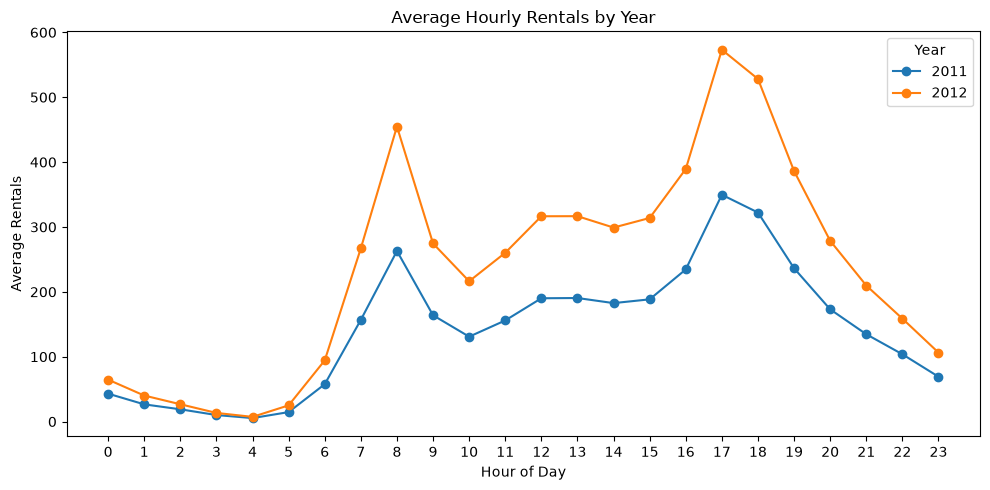

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))

for year in sorted(hourly_rentals_by_year["year"].unique()):
    yearly_data = hourly_rentals_by_year[hourly_rentals_by_year["year"] == year]

    ax.plot(
        yearly_data["hr"],
        yearly_data["avg_hourly_rentals"],
        marker="o",
        label=str(year),
    )

ax.set_title("Average Hourly Rentals by Year")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Rentals")
ax.set_xticks(range(24))
ax.legend(title="Year")

fig.tight_layout()

save_fig(fig, "q2_average_hourly_rentals_by_year")

plt.show()


### Peak Hourly Demand by Year


In [47]:
peak_hour_idx_by_year = hourly_rentals_by_year.groupby("year")[
    "avg_hourly_rentals"
].idxmax()

peak_hour_idx_by_year


year
2011    17
2012    41
Name: avg_hourly_rentals, dtype: int64

In [48]:
peak_hour_by_year = hourly_rentals_by_year.loc[peak_hour_idx_by_year]

peak_hour_by_year["avg_hourly_rentals"] = peak_hour_by_year[
    "avg_hourly_rentals"
].round()

peak_hour_by_year = peak_hour_by_year.set_index("year")

peak_hour_by_year


,hr,avg_hourly_rentals
year,,
2011,17,350.0
2012,17,573.0


### Hourly Rental Patterns by User Type and Year


In [49]:
hourly_rentals_by_user_type = hourly_df.groupby(["year", "hr"], as_index=False).agg(
    avg_casual_rentals=("casual", "mean"),
    avg_registered_rentals=("registered", "mean"),
)

hourly_rentals_by_user_type.head()


,year,hr,avg_casual_rentals,avg_registered_rentals
0,2011,0,9.481994,33.565097
1,2011,1,5.752778,20.797222
2,2011,2,4.460227,14.463068
3,2011,3,2.789474,7.271930
4,2011,4,1.278932,4.112760


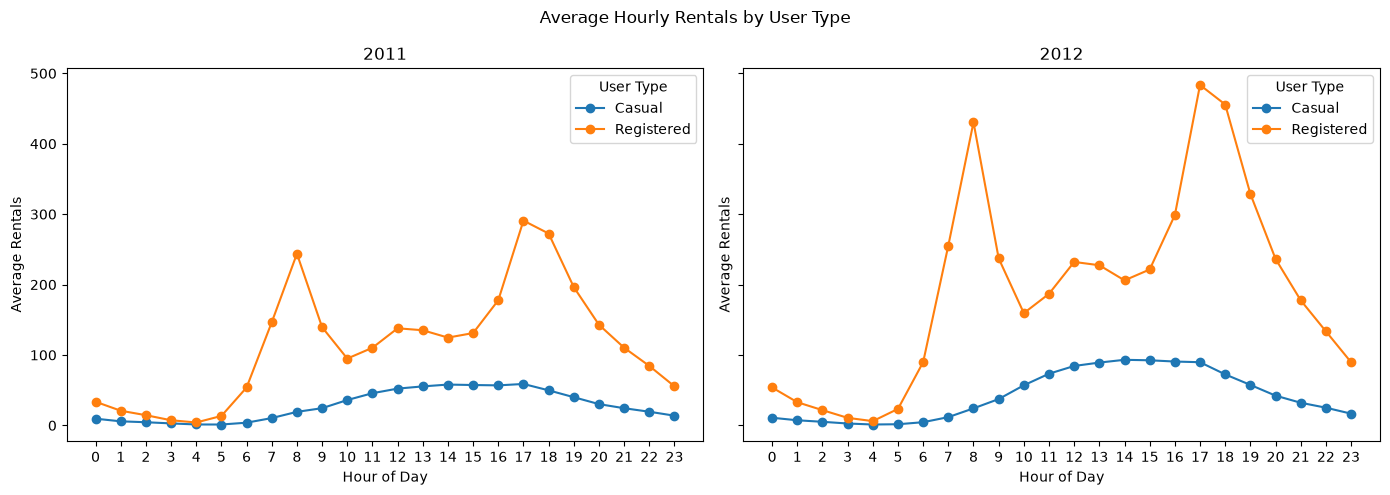

In [50]:
years = sorted(hourly_rentals_by_user_type["year"].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, year in zip(axes, years):
    yearly_data = hourly_rentals_by_user_type[
        hourly_rentals_by_user_type["year"] == year
    ]

    ax.plot(
        yearly_data["hr"],
        yearly_data["avg_casual_rentals"],
        marker="o",
        label="Casual",
    )

    ax.plot(
        yearly_data["hr"],
        yearly_data["avg_registered_rentals"],
        marker="o",
        label="Registered",
    )

    ax.set_title(str(year))
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Average Rentals")
    ax.set_xticks(range(24))
    ax.legend(title="User Type")

fig.suptitle("Average Hourly Rentals by User Type")

plt.tight_layout()

save_fig(fig, "q2_average_hourly_rentals_by_user_type")

plt.show()


### Hourly Rental Patterns by Day Type and Year


In [51]:
hourly_rentals_by_day_type = hourly_df.groupby(
    ["year", "day_type", "hr"],
    as_index=False,
).agg(avg_hourly_rentals=("cnt", "mean"))

hourly_rentals_by_day_type.head()


,year,day_type,hr,avg_hourly_rentals
0,2011,Non-Working Day,0,72.780702
1,2011,Non-Working Day,1,54.228070
2,2011,Non-Working Day,2,43.053097
3,2011,Non-Working Day,3,21.601770
4,2011,Non-Working Day,4,6.633929


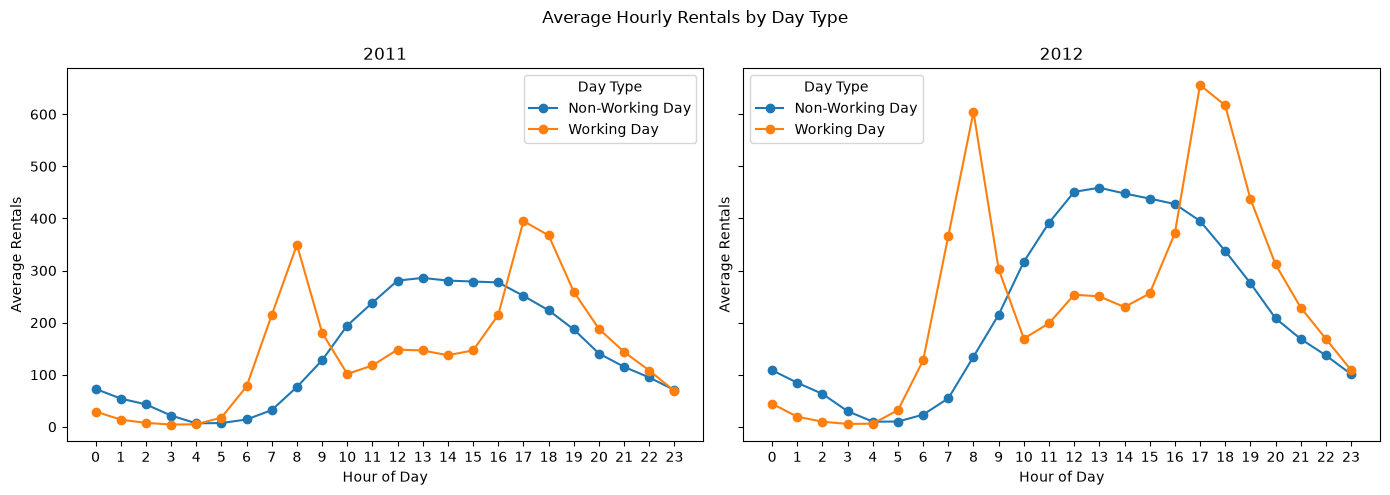

In [52]:
years = sorted(hourly_rentals_by_day_type["year"].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, year in zip(axes, years):
    yearly_data = hourly_rentals_by_day_type[hourly_rentals_by_day_type["year"] == year]

    for day_type in sorted(yearly_data["day_type"].unique()):
        day_type_data = yearly_data[yearly_data["day_type"] == day_type]

        ax.plot(
            day_type_data["hr"],
            day_type_data["avg_hourly_rentals"],
            marker="o",
            label=day_type,
        )

    ax.set_title(str(year))
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Average Rentals")
    ax.set_xticks(range(24))
    ax.legend(title="Day Type")

fig.suptitle("Average Hourly Rentals by Day Type")

plt.tight_layout()

save_fig(fig, "q2_average_hourly_rentals_by_day_type")

plt.show()


### Hourly Rental Patterns by User Type and Day Type


In [53]:
hourly_rentals_by_user_and_day_type = hourly_df.groupby(
    ["year", "day_type", "hr"],
    as_index=False,
).agg(
    avg_casual_rentals=("casual", "mean"),
    avg_registered_rentals=("registered", "mean"),
)

hourly_rentals_by_user_and_day_type.head()


,year,day_type,hr,avg_casual_rentals,avg_registered_rentals
0,2011,Non-Working Day,0,15.701754,57.078947
1,2011,Non-Working Day,1,10.587719,43.640351
2,2011,Non-Working Day,2,9.407080,33.646018
3,2011,Non-Working Day,3,6.380531,15.221239
4,2011,Non-Working Day,4,2.026786,4.607143


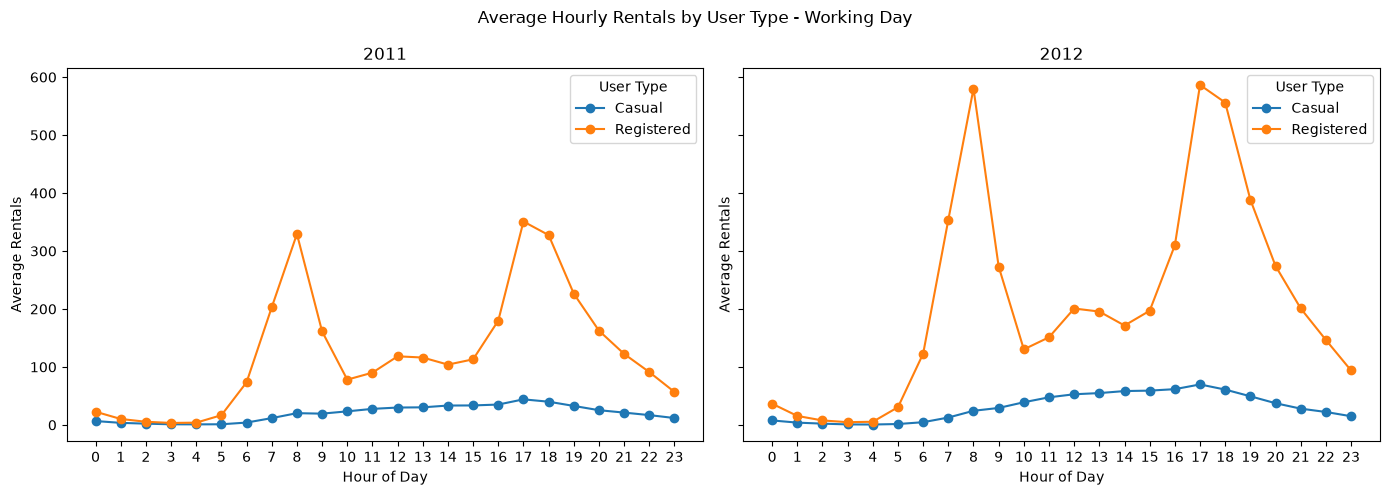

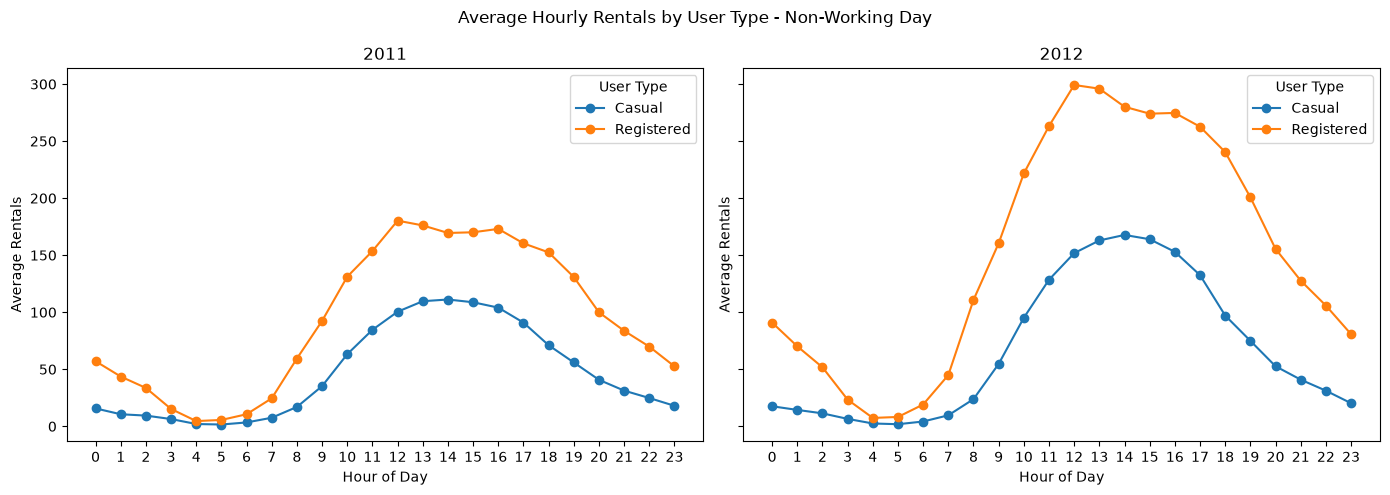

In [54]:
day_type_order = ["Working Day", "Non-Working Day"]
years = sorted(hourly_rentals_by_user_and_day_type["year"].unique())

for day_type in day_type_order:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, year in zip(axes, years):
        chart_data = hourly_rentals_by_user_and_day_type[
            (hourly_rentals_by_user_and_day_type["year"] == year)
            & (hourly_rentals_by_user_and_day_type["day_type"] == day_type)
        ]

        ax.plot(
            chart_data["hr"],
            chart_data["avg_casual_rentals"],
            marker="o",
            label="Casual",
        )

        ax.plot(
            chart_data["hr"],
            chart_data["avg_registered_rentals"],
            marker="o",
            label="Registered",
        )

        ax.set_title(str(year))
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel("Average Rentals")
        ax.set_xticks(range(24))
        ax.legend(title="User Type")

    fig.suptitle(f"Average Hourly Rentals by User Type - {day_type}")

    plt.tight_layout()

    save_fig(
        fig,
        f"q2_average_hourly_rentals_by_user_type_-_{day_type.lower().replace(' ', '_')}",
    )

    plt.show()


# 📊 3. Data Visualization


## 3.1 Outlier Assessment


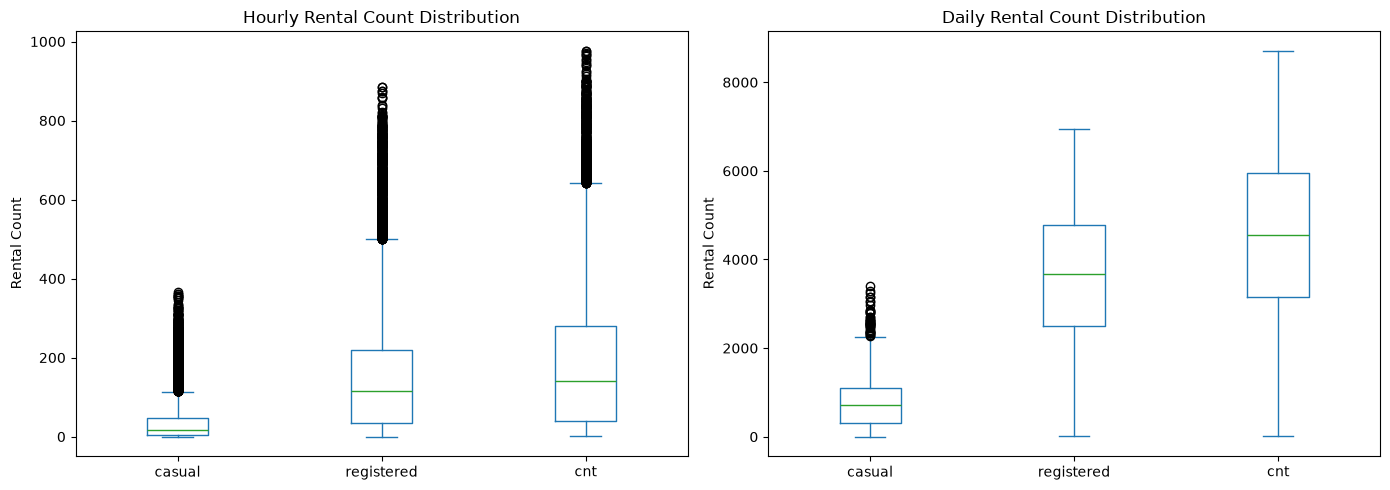

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_df[RENTAL_COLUMNS].plot(kind="box", ax=axes[0])

axes[0].set_title("Hourly Rental Count Distribution")
axes[0].set_ylabel("Rental Count")

daily_df[RENTAL_COLUMNS].plot(kind="box", ax=axes[1])

axes[1].set_title("Daily Rental Count Distribution")
axes[1].set_ylabel("Rental Count")

plt.tight_layout()

save_fig(fig, "rental_count_distribution")

plt.show()


## 3.2 Dataset Summary Statistics


In [56]:
def plot_summary_table(summary, title, filename, figsize, title_pad):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=summary.values,
        colLabels=summary.columns,
        cellLoc="center",
        loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(12)

    # Format table cells first.
    for (row, col), cell in table.get_celld().items():
        cell.set_height(0.12)

    # Format header row.
    for col in range(len(summary.columns)):
        table[(0, col)].set_height(0.18)
        table[(0, col)].set_text_props(weight="bold")

    ax.set_title(title, pad=title_pad)

    plt.tight_layout()

    save_fig(fig, filename)

    plt.show()


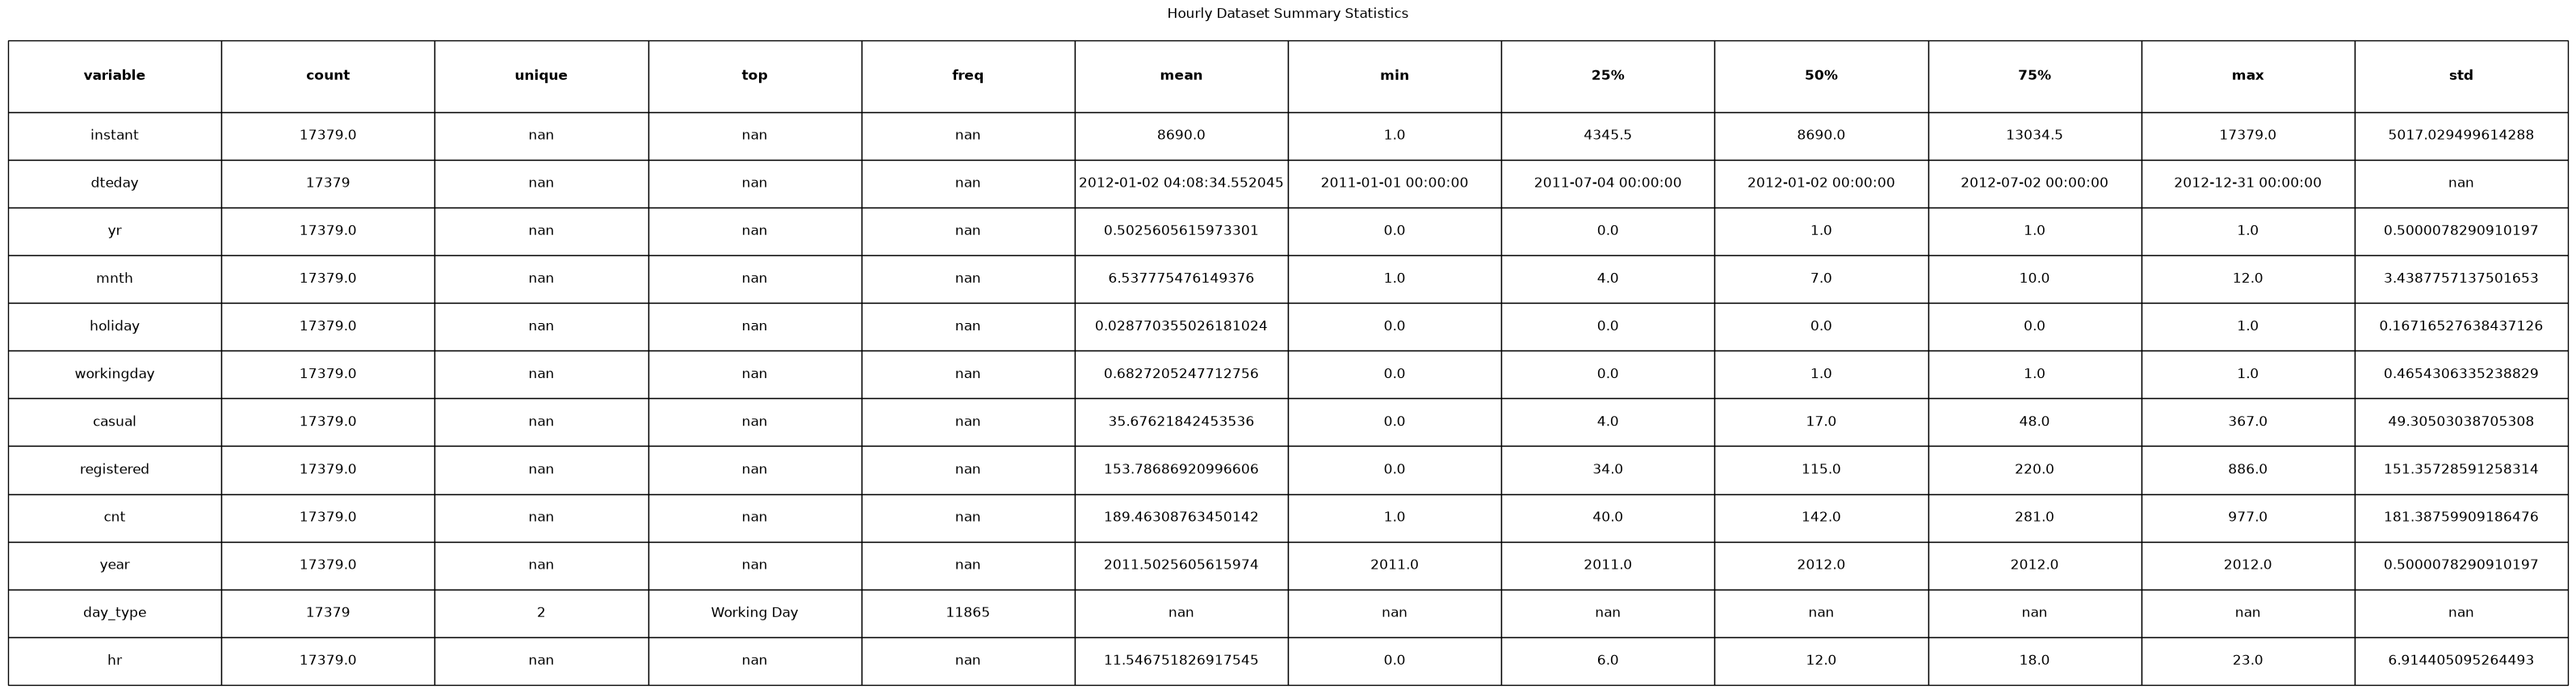

In [57]:
hourly_summary = (
    hourly_df[HOURLY_VARIABLES].describe(include="all").T.reset_index(names="variable")
)

plot_summary_table(
    hourly_summary,
    "Hourly Dataset Summary Statistics",
    "hourly_dataset_summary_statistics",
    figsize=(32, 10),
    title_pad=130,
)


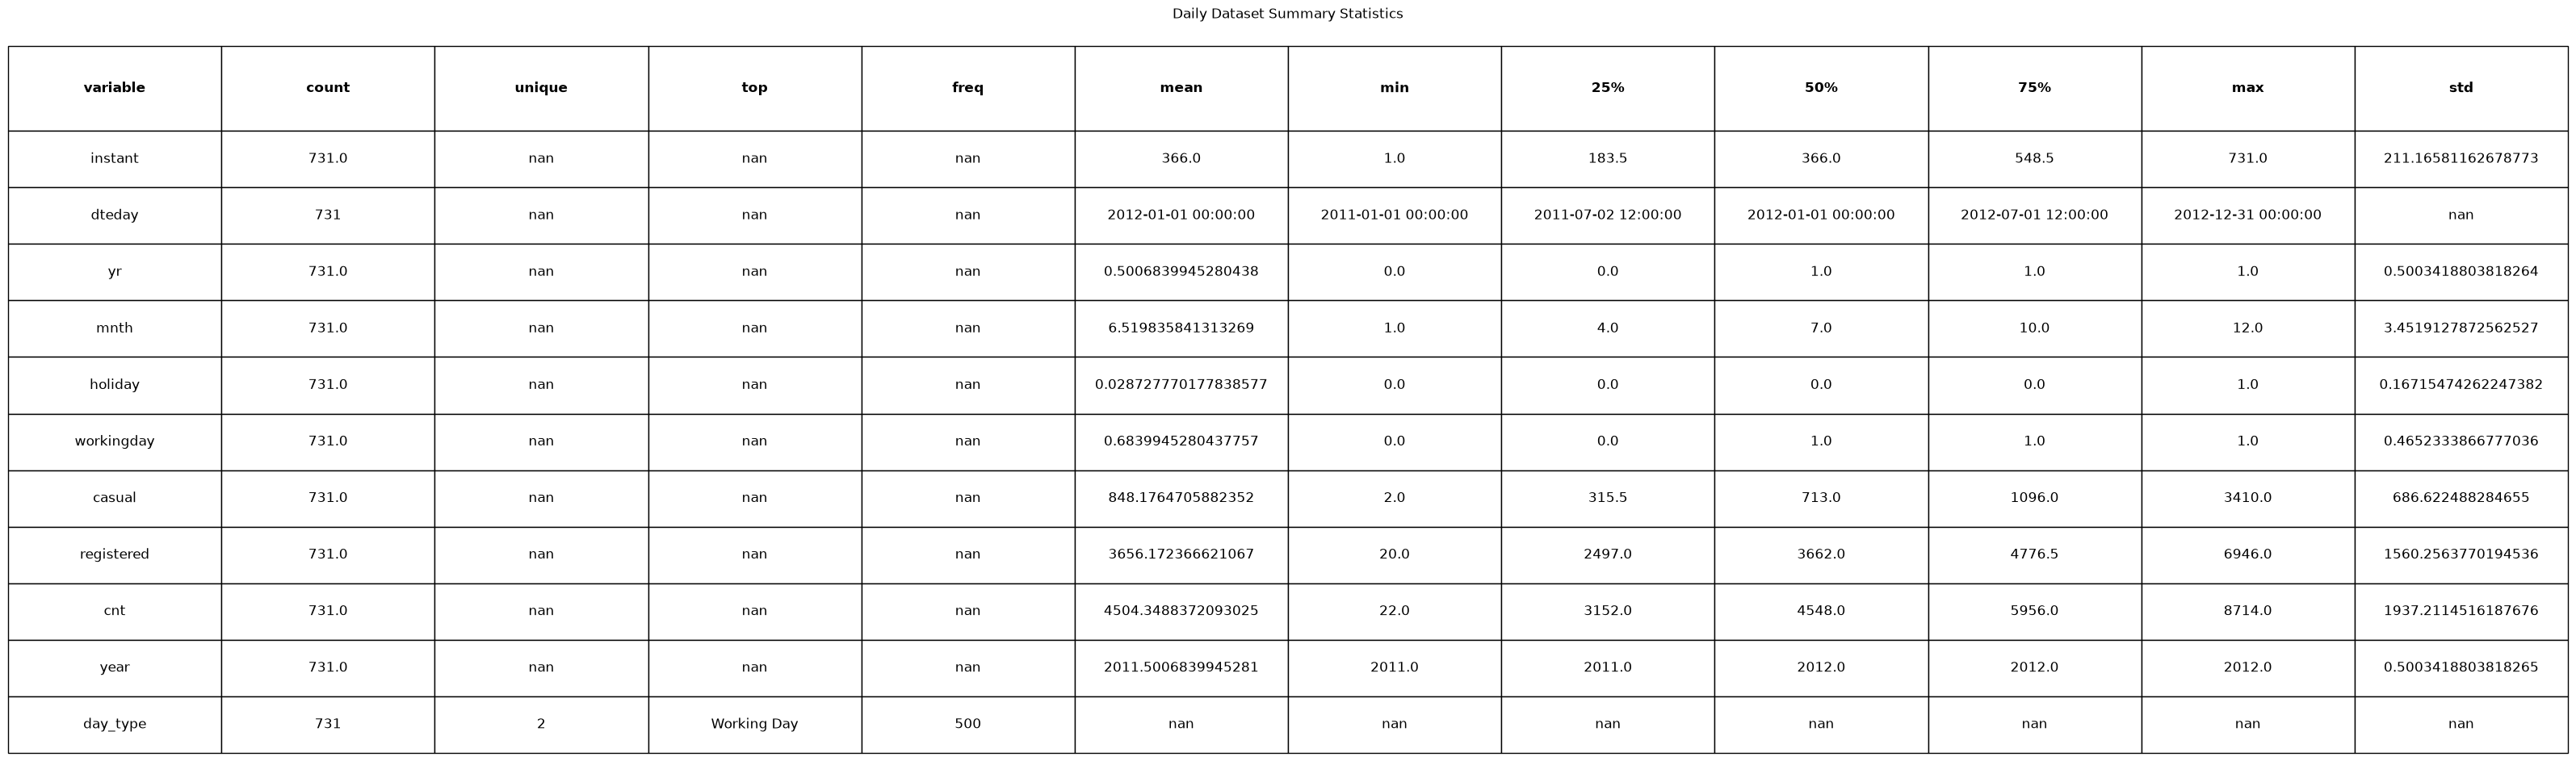

In [58]:
daily_summary = (
    daily_df[DAILY_VARIABLES].describe(include="all").T.reset_index(names="variable")
)

plot_summary_table(
    daily_summary,
    "Daily Dataset Summary Statistics",
    "daily_dataset_summary_statistics",
    figsize=(32, 10),
    title_pad=130,
)


## 3.3 Annual Rental Demand, User Composition, and Growth by User Type


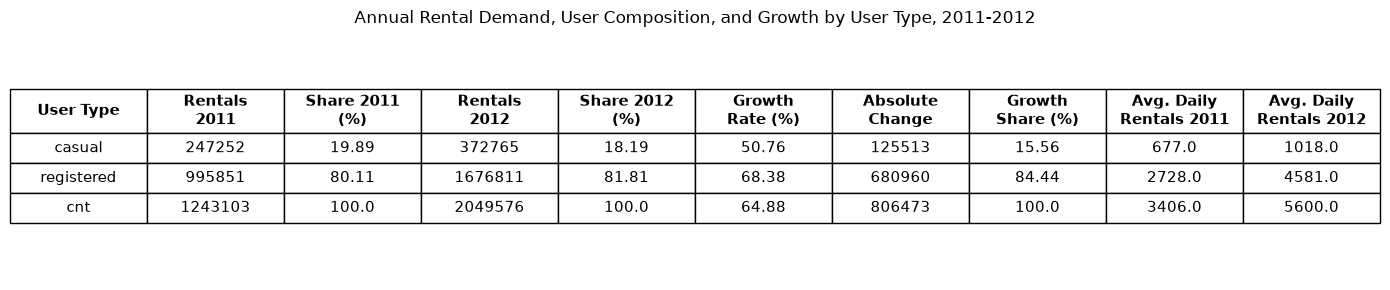

In [59]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis("off")

labels = [
    "User Type",
    "Rentals\n2011",
    "Share 2011\n(%)",
    "Rentals\n2012",
    "Share 2012\n(%)",
    "Growth\nRate (%)",
    "Absolute\nChange",
    "Growth\nShare (%)",
    "Avg. Daily\nRentals 2011",
    "Avg. Daily\nRentals 2012",
]

table = ax.table(
    cellText=summary.values, colLabels=labels, cellLoc="center", loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)

for (row, col), cell in table.get_celld().items():
    cell.set_height(0.12)

for col in range(len(labels)):
    table[(0, col)].set_height(0.18)
    table[(0, col)].set_text_props(weight="bold")


ax.set_title(
    "Annual Rental Demand, User Composition, and Growth by User Type, 2011-2012"
)

plt.tight_layout()

save_fig(
    fig,
    "q1_annual_rental_demand_user_composition_and_growth_by_user_type_2011-2012.png",
)

plt.show()


## 3.4 Annual Rentals by User Type


In [60]:
annual_rentals_by_user_type = daily_df.groupby("year", as_index=False).agg(
    casual_rentals=("casual", "sum"),
    registered_rentals=("registered", "sum"),
    total_rentals=("cnt", "sum"),
)

annual_rentals_by_user_type


,year,casual_rentals,registered_rentals,total_rentals
0,2011,247252,995851,1243103
1,2012,372765,1676811,2049576


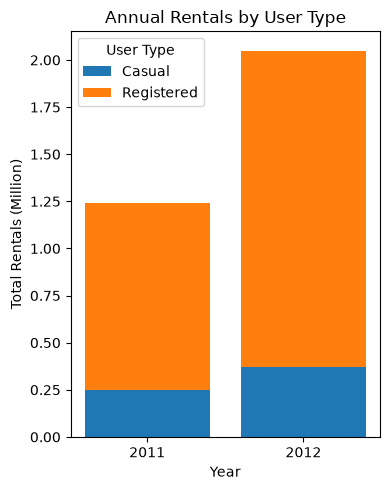

In [61]:
fig, ax = plt.subplots(figsize=(4, 5))

ax.bar(
    annual_rentals_by_user_type["year"].astype(str),
    annual_rentals_by_user_type["casual_rentals"] / 1e6,
    label="Casual",
)

ax.bar(
    annual_rentals_by_user_type["year"].astype(str),
    annual_rentals_by_user_type["registered_rentals"] / 1e6,
    bottom=annual_rentals_by_user_type["casual_rentals"] / 1e6,
    label="Registered",
)

ax.set_title("Annual Rentals by User Type")
ax.set_xlabel("Year")
ax.set_ylabel("Total Rentals (Million)")
ax.legend(title="User Type")

plt.tight_layout()

save_fig(fig, "q1_annual_rentals_by_user_type")

plt.show()
